# **Objective**
We are building a Career Coach AI agent at PeopleCert. Its role is to guide learners through their certification journey, recommending the next best certificates based on who they are, what they’ve done, and what’s available right now.
The task is to prototype a simplified version of this system using synthetic data.




# **1.	Data exploration**

In [ ]:
import warnings #Used to ignore the warning given as output of the code.
warnings.filterwarnings('ignore')

import numpy as np # Basic libraries of python for numeric and dataframe computations.
import pandas as pd

import matplotlib.pyplot as plt #Basic library for data visualization.
import seaborn as sns #Slightly advanced library for data visualization

from sklearn.metrics.pairwise import cosine_similarity #To compute the cosine similarity between two vectors.
from collections import defaultdict #A dictionary output that does not raise a key error


In [ ]:
#importing the datasets
cat_df=pd.read_csv('catalog.csv')
purch_df=pd.read_csv('purchases.csv')
signal_df=pd.read_csv('signals.csv')
user_df=pd.read_csv('users.csv')

### **Understanding the data by viewing a few observations**

In [ ]:
cat_df.head()

,cert_id,name,family,level,skills,languages,prerequisites,price,duration_hours,short_desc
0,ITILF,ITIL Foundation,ITIL,Foundation,service operations|service design|problem mana...,en-GB|es-ES,NaN,452,12,ITIL Foundation course covering service operat...
1,ITILP,ITIL Practitioner,ITIL,Practitioner,service design|incident management|SLA|problem...,en-GB|hi-IN|ar-AE|en-US|it-IT,ITILF,729,24,ITIL Practitioner course covering service desi...
2,ITILL,ITIL Leader,ITIL,Leader,incident management|change enablement|ITSM|ser...,ar-AE|es-ES|nl-NL,ITILF,792,20,ITIL Leader course covering incident managemen...
3,PRINCE2F,PRINCE2 Foundation,PRINCE2,Foundation,project governance|planning|quality management...,de-DE|it-IT|en-GB,NaN,364,20,PRINCE2 Foundation course covering project gov...
4,PRINCE2P,PRINCE2 Practitioner,PRINCE2,Practitioner,planning|project governance|project controls|r...,ar-AE|en-US,PRINCE2F,656,20,"PRINCE2 Practitioner course covering planning,..."


In [ ]:
purch_df.head()

,user_id,cert_id,purchase_date,order_id
0,U0001,PRINCE2F,2024-02-12,OU0001A
1,U0001,PRINCE2P,2024-04-07,OU0001B
2,U0002,MoVF,2022-03-25,OU0002A
3,U0003,DevOpsF,2023-03-30,OU0003A
4,U0004,MoVF,2023-03-11,OU0004A


In [ ]:
signal_df.head()

,timestamp,user_id,cert_id,event
0,2024-02-05,U0001,PRINCE2F,impression
1,2024-02-06,U0001,PRINCE2F,click
2,2024-02-09,U0001,PRINCE2F,add_to_cart
3,2024-02-12,U0001,PRINCE2F,purchase
4,2024-03-31,U0001,PRINCE2P,impression


In [ ]:
user_df.head()

,user_id,role,skills,country,language,goal,years_experience,industry
0,U0001,Business Analyst,release management|planning,Italy,nl-NL,become a project manager,3,Healthcare
1,U0002,Service Desk Analyst,incident management|SLA|ITSM|stakeholder engag...,Germany,hi-IN,move into ITSM,4,Manufacturing
2,U0003,Business Analyst,observability|benefits,USA,de-DE,become a project manager,4,Telecom
3,U0004,IT Manager,governance|benefits management|stakeholder eng...,UK,it-IT,transition to DevOps,6,IT Services
4,U0005,IT Support Specialist,incident management|SLA|ITSM|prioritization|ob...,Spain,en-GB,become a project manager,6,Public Sector


**Check the data types and and missing values of each column**

In [ ]:
cat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   cert_id         12 non-null     object
 1   name            12 non-null     object
 2   family          12 non-null     object
 3   level           12 non-null     object
 4   skills          12 non-null     object
 5   languages       12 non-null     object
 6   prerequisites   6 non-null      object
 7   price           12 non-null     int64 
 8   duration_hours  12 non-null     int64 
 9   short_desc      12 non-null     object
dtypes: int64(2), object(8)
memory usage: 1.1+ KB


There are some missing values in prerequisites column. Nan means that the course has NO prerequisites. I will replace Nan with empty string

In [ ]:
cat_df['prerequisites'] = cat_df['prerequisites'].fillna('')

In [ ]:
purch_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   user_id        300 non-null    object
 1   cert_id        300 non-null    object
 2   purchase_date  300 non-null    object
 3   order_id       300 non-null    object
dtypes: object(4)
memory usage: 9.5+ KB


In [ ]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user_id           200 non-null    object
 1   role              200 non-null    object
 2   skills            200 non-null    object
 3   country           200 non-null    object
 4   language          200 non-null    object
 5   goal              200 non-null    object
 6   years_experience  200 non-null    int64 
 7   industry          200 non-null    object
dtypes: int64(1), object(7)
memory usage: 12.6+ KB


In [ ]:
signal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  1200 non-null   object
 1   user_id    1200 non-null   object
 2   cert_id    1200 non-null   object
 3   event      1200 non-null   object
dtypes: object(4)
memory usage: 37.6+ KB


Merging the tables

In [ ]:
df = pd.merge(cat_df, purch_df, on="cert_id", how="left")

df2=pd.merge(df,user_df,on=['user_id'],how="left")

In [ ]:
df2.columns

Index(['cert_id', 'name', 'family', 'level', 'skills_x', 'languages',
       'prerequisites', 'price', 'duration_hours', 'short_desc', 'user_id',
       'purchase_date', 'order_id', 'role', 'skills_y', 'country', 'language',
       'goal', 'years_experience', 'industry'],
      dtype='object')

In [ ]:
#Rename skills_x which are taught skills and skills_y which are the skills the user has
df2=df2.rename(columns={'skills_x':'certificate_skills','skills_y':'user_skills'})

In [ ]:
eda_df=pd.merge(df2,signal_df,on=['user_id','cert_id'],how='left')

In [ ]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1880 entries, 0 to 1879
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   cert_id             1880 non-null   object
 1   name                1880 non-null   object
 2   family              1880 non-null   object
 3   level               1880 non-null   object
 4   certificate_skills  1880 non-null   object
 5   languages           1880 non-null   object
 6   prerequisites       1880 non-null   object
 7   price               1880 non-null   int64 
 8   duration_hours      1880 non-null   int64 
 9   short_desc          1880 non-null   object
 10  user_id             1880 non-null   object
 11  purchase_date       1880 non-null   object
 12  order_id            1880 non-null   object
 13  role                1880 non-null   object
 14  user_skills         1880 non-null   object
 15  country             1880 non-null   object
 16  language            1880

 Check the total number of unique users, certificates, orders in the data

In [ ]:
eda_df['user_id'].nunique()

155

In [ ]:
eda_df['cert_id'].nunique()

12

In [ ]:
eda_df['order_id'].nunique()

300

155 users, 12 certificates, 300 orders

Find out about the most interacted certificates and interacted users or interacted roles

In [ ]:
eda_df['name'].value_counts()

,count
name,
MSP Practitioner,332
DevOps Practitioner,312
MoV Foundation,288
PRINCE2 Practitioner,184
MSP Foundation,124
Scrum Master,124
DevOps Foundation,116
Scrum Foundation,104
ITIL Foundation,96


In [ ]:
eda_df['role'].value_counts()

,count
role,
SRE/DevOps Engineer,256
Business Analyst,236
Project Manager,228
Scrum Master,152
Software Developer,152
IT Manager,144
QA Engineer,136
Service Desk Analyst,128
IT Support Specialist,124


In [ ]:
eda_df['user_id'].value_counts()

,count
user_id,
U0049,104
U0194,68
U0176,68
U0192,68
U0129,68
...,...
U0083,4
U0088,4
U0085,4


#### **Observations and Insights:**
- The certificate  'MSP Practitioner' has been chosen the most number of times.
- The user with ID 61472 is the most interacted user and is a project Manager.
- The role which is most interacted is the one of SRE/DevOps Engineer

In [ ]:
count_c = eda_df.groupby('price').count()['cert_id']
count = pd.DataFrame(count_c)
count.drop(count.index[0], inplace=True)
count.tail()

,cert_id
price,
652,124
656,184
729,56
738,312
792,60


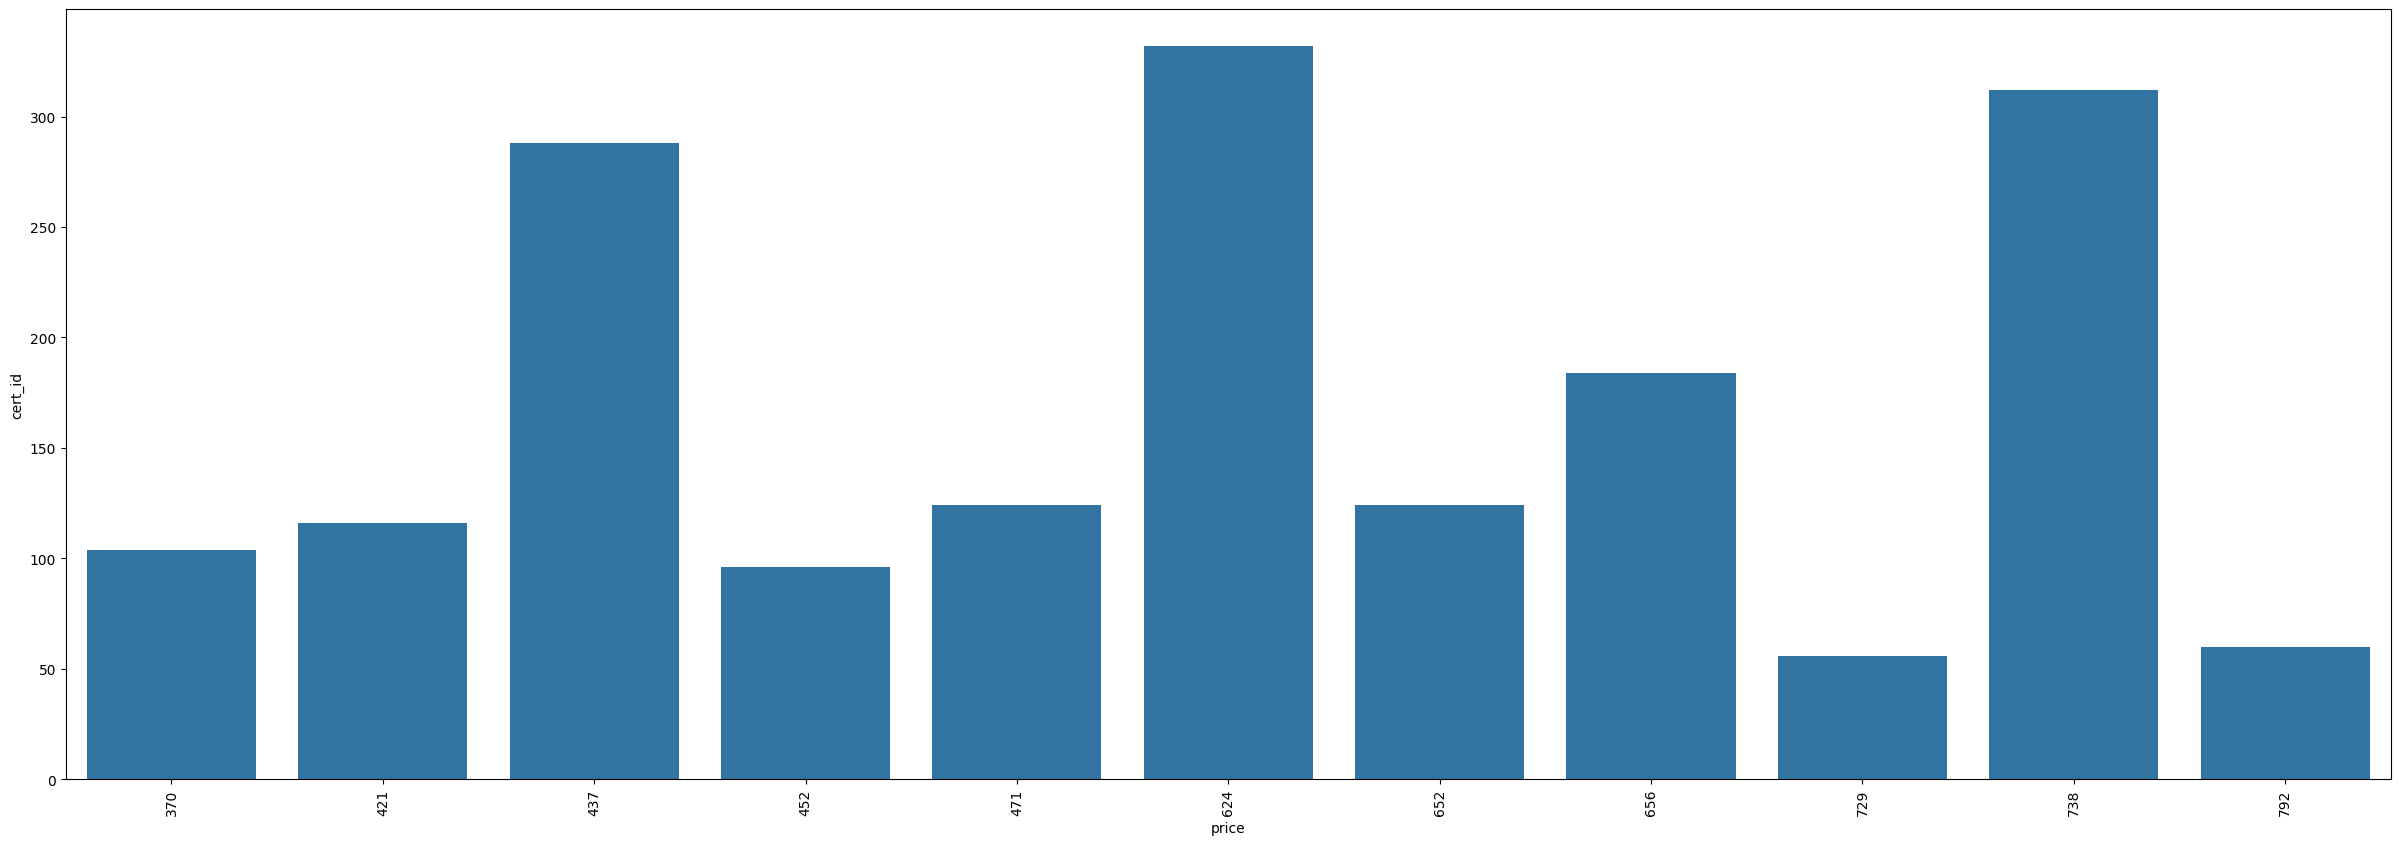

In [ ]:
plt.figure(figsize=(30,10))
ax = sns.barplot(x = count.index,
            y = 'cert_id',
            data = count,
            estimator = np.median,)
for item in ax.get_xticklabels(): item.set_rotation(90)
#plt.ylabel('number of songs released')
# Show the plot
plt.show()

**Observations and Insights:**

We can observe that most of the certificates have a middle price not to low/not to high ->624

However there are two more categories 1. many certificates have lower price ->421 2. There are many certificates with higher price ->738




In [ ]:
count_h = eda_df.groupby('duration_hours').count()['cert_id']
count = pd.DataFrame(count_h)
count.drop(count.index[0], inplace=True)
count.tail()

,cert_id
duration_hours,
16,644
20,968
24,56


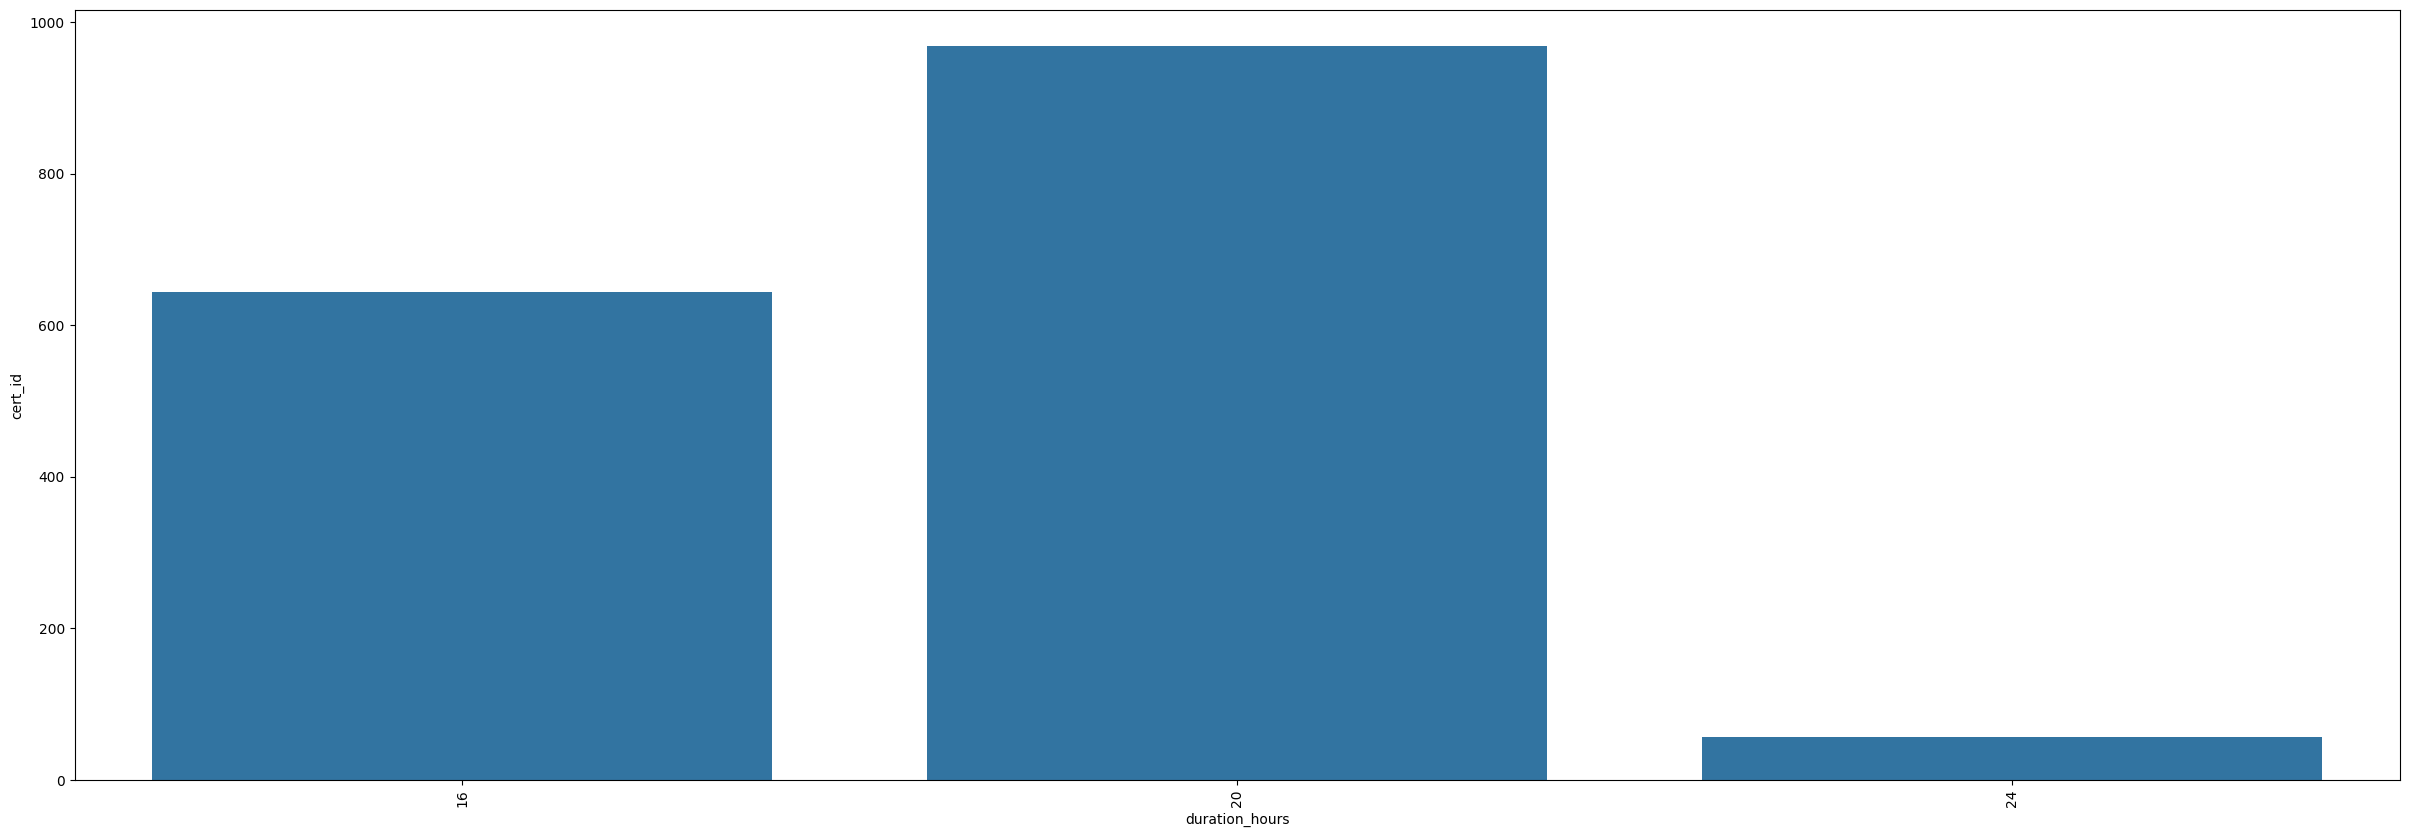

In [ ]:
plt.figure(figsize=(30,10))
ax = sns.barplot(x = count.index,
            y = 'cert_id',
            data = count,
            estimator = np.median,)
for item in ax.get_xticklabels(): item.set_rotation(90)
#plt.ylabel('number of songs released')
# Show the plot
plt.show()

**Observations and Insights:**
We can observe that most certificates last 20 hours, suggesting a relatively standardized study commitment across the catalog. Some certificates require significantly more or less time, but the 20-hour duration is the clear mode, which may reflect an intentional design choice for foundational-level certifications.


# **2.	Candidate generation**
a. Content-Based Candidate Generation

In [ ]:
#users
user_df['profile_text'] = (
    user_df['role'].fillna('') + ' ' +
    user_df['skills'].fillna('') + ' ' +
    user_df['goal'].fillna('')
)

In [ ]:
user_df['profile_text'][0]

'Business Analyst release management|planning become a project manager'

In [ ]:
#certificates
cat_df['cert_text'] = (
    cat_df['name'].fillna('') + ' ' +
    cat_df['skills'].fillna('') + ' ' +
    cat_df['short_desc'].fillna('')
)

In [ ]:
cat_df['cert_text'][0]

'ITIL Foundation service operations|service design|problem management|ITSM|incident management ITIL Foundation course covering service operations, service design, problem management, ITSM, incident management.'

In [ ]:
all_text = pd.concat([user_df['profile_text'], cat_df['cert_text']])

In [ ]:
all_text

,0
0,Business Analyst release management|planning b...
1,Service Desk Analyst incident management|SLA|I...
2,Business Analyst observability|benefits become...
3,IT Manager governance|benefits management|stak...
4,IT Support Specialist incident management|SLA|...
...,...
7,Scrum Foundation story points|scrum ceremonies...
8,Scrum Master scrum ceremonies|agile|retrospect...
9,MSP Foundation stakeholder engagement|benefits...
10,MSP Practitioner stakeholder engagement|progra...


Convert to vectors (TF-IDF) the all_text content

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

vectorizer.fit(all_text)

user_vectors = vectorizer.transform(user_df['profile_text'])
cert_vectors = vectorizer.transform(cat_df['cert_text'])

Compute similatity matrix

In [ ]:
similarity_matrix = cosine_similarity(user_vectors, cert_vectors)

In [ ]:
similarity_matrix[0]

array([0.03766634, 0.03670614, 0.01805591, 0.23860161, 0.20121062,
       0.        , 0.        , 0.        , 0.06569464, 0.11811647,
       0.09897609, 0.01759871])

In [ ]:
def get_content_candidates(user_id, top_n=5):
    user_idx = user_df[user_df['user_id'] == user_id].index[0]

    scores = similarity_matrix[user_idx]

    top_indices = scores.argsort()[::-1][:top_n]

    return cat_df.iloc[top_indices][['cert_id', 'name']]

In [ ]:
x=user_df['user_id'][0]
get_content_candidates(x)

,cert_id,name
3,PRINCE2F,PRINCE2 Foundation
4,PRINCE2P,PRINCE2 Practitioner
9,MSPF,MSP Foundation
10,MSPP,MSP Practitioner
8,ScrumM,Scrum Master


We can see that for example for the first user who is a Business Analyst with release management|planning skills and his/her goal is to become a project manager one of the certificates reccomended mostly  is PRINCE2 Foundation includes project governance, planning,quality management,risk management,business case skills

b. Co-occurrence

In [ ]:
#user purchase lists
user_cert_map = purch_df.groupby('user_id')['cert_id'].apply(list)
user_cert_map

,cert_id
user_id,
U0001,"[PRINCE2F, PRINCE2P]"
U0002,[MoVF]
U0003,[DevOpsF]
U0004,[MoVF]
U0005,"[ScrumF, ScrumM]"
...,...
U0196,"[ScrumF, ScrumM]"
U0197,"[ScrumF, ScrumM]"
U0198,"[ScrumF, ScrumM, ScrumM]"


In [ ]:
from collections import defaultdict

co_occurrence = defaultdict(lambda: defaultdict(int))

for certs in user_cert_map.values:
    for i in certs:
        for j in certs:
            if i != j:
                co_occurrence[i][j] += 1

In [ ]:
co_occurrence

defaultdict(<function __main__.<lambda>()>,
            {'PRINCE2F': defaultdict(int, {'PRINCE2P': 22}),
             'PRINCE2P': defaultdict(int, {'PRINCE2F': 22}),
             'ScrumF': defaultdict(int, {'ScrumM': 17}),
             'ScrumM': defaultdict(int, {'ScrumF': 17}),
             'ITILF': defaultdict(int, {'ITILP': 14, 'ITILL': 9}),
             'ITILP': defaultdict(int, {'ITILF': 14, 'ITILL': 9}),
             'DevOpsF': defaultdict(int, {'DevOpsP': 34}),
             'DevOpsP': defaultdict(int, {'DevOpsF': 34}),
             'MSPF': defaultdict(int, {'MSPP': 35}),
             'MSPP': defaultdict(int, {'MSPF': 35}),
             'ITILL': defaultdict(int, {'ITILF': 9, 'ITILP': 9})})

In [ ]:
def get_cooccurrence_candidates(user_id, top_n=5):
    user_certs = purch_df[purch_df['user_id'] == user_id]['cert_id'].tolist()

    scores = defaultdict(int)

    for cert in user_certs:
        for related_cert, count in co_occurrence[cert].items():
            scores[related_cert] += count

    # sort
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    return ranked[:top_n]

In [ ]:
x=purch_df['user_id'][0]
get_cooccurrence_candidates(x)

[('PRINCE2P', 22), ('PRINCE2F', 22)]

# 3. Ranking

I considered clustering-based approaches such as KMeans to group certificates based on similarity in skills and descriptions. However, due to the small size of the dataset and the requirement for personalized recommendations based on user profiles and purchase history, I will not include KMeans in the final model. Instead, I will adopt a hybrid recommender combining content-based similarity, co-occurrence patterns, and interaction-based popularity scores, which better capture user-specific preferences and learning pathways.

We need to consider
*  the user’s role
*  the user’s skills
*  purchase history
*  the user’s goal
*  prerequisites

Also we should consider a global popularity score purchase count, click count, add_to_cart count

A) Content score between User profile text and Certificate text



In [ ]:
# from Task 2 i borow the similarity_matrix that i computed and create a df with values the similarity scores

content_score_df = pd.DataFrame(
   similarity_matrix,
    index=user_df['user_id'],
    columns=cat_df['cert_id']
)

content_score_df.head()

cert_id,ITILF,ITILP,ITILL,PRINCE2F,PRINCE2P,DevOpsF,DevOpsP,ScrumF,ScrumM,MSPF,MSPP,MoVF
user_id,,,,,,,,,,,,
U0001,0.037666,0.036706,0.018056,0.238602,0.201211,0.000000,0.000000,0.0,0.065695,0.118116,0.098976,0.017599
U0002,0.280122,0.263048,0.196768,0.223611,0.027966,0.000000,0.000000,0.0,0.000000,0.162914,0.150488,0.012247
U0003,0.000000,0.000000,0.000000,0.137996,0.104590,0.000000,0.164902,0.0,0.000000,0.140964,0.080656,0.053247
U0004,0.071137,0.030356,0.053269,0.128148,0.122165,0.054098,0.054285,0.0,0.196535,0.178647,0.154584,0.057426
U0005,0.125025,0.145087,0.107085,0.067640,0.100520,0.000000,0.113637,0.0,0.000000,0.028629,0.014473,0.141768


In [ ]:


def get_user_purchases(user_id):
    """Return the set of cert_ids already purchased by the user."""
    return set(
        purch_df[purch_df['user_id'] == user_id]['cert_id'].astype(str).tolist()
    )


def has_prerequisites(user_id, cert_id):
    """
    Check whether the user satisfies the prerequisites for a certificate.

    """
    user_purchases = get_user_purchases(user_id)

    prereq_value = cat_df.loc[cat_df['cert_id'] == cert_id, 'prerequisites'].iloc[0]

    if pd.isna(prereq_value) or str(prereq_value).strip() == '':
        return True

    required_certs = set(str(prereq_value).split('|'))
    return required_certs.issubset(user_purchases)


def recommend_content_based(user_id, top_k=5):
    """
    Recommend top_k certificates using content similarity,
    excluding already purchased certificates and enforcing prerequisites.
    """
    # Get similarity scores for this user
    user_scores = content_score_df.loc[user_id].sort_values(ascending=False)

    user_purchases = get_user_purchases(user_id)
    recommendations = []

    for cert_id, score in user_scores.items():
        # Rule 1: exclude already purchased certificates
        if cert_id in user_purchases:
            continue

        # Rule 2: enforce prerequisites
        if not has_prerequisites(user_id, cert_id):
            continue

        cert_info = cat_df[cat_df['cert_id'] == cert_id].iloc[0]

        recommendations.append({
            'cert_id': cert_id,
            'name': cert_info['name'],
            'content_score': round(score, 3)
        })

        if len(recommendations) == top_k:
            break

    return pd.DataFrame(recommendations)

In [ ]:
recommend_content_based(user_df['user_id'].iloc[0], top_k=5)

,cert_id,name,content_score
0,MSPF,MSP Foundation,0.118
1,ITILF,ITIL Foundation,0.038
2,MoVF,MoV Foundation,0.018
3,ScrumF,Scrum Foundation,0.000
4,DevOpsF,DevOps Foundation,0.000


B)Co-occurrence score for a user and candidate cert

1)For a user get all purchased certs
2)For a candidate cert, sum how often it co-occurs with the user’s purchased certs

In [ ]:
def get_cooccurrence_score(user_id, candidate_cert_id):
    user_purchases = get_user_purchases(user_id)

    score = 0
    for purchased_cert in user_purchases:
        score += co_occurrence[purchased_cert].get(candidate_cert_id, 0)

    return score

In [ ]:
max_cooccurrence = max(
    [count for related in co_occurrence.values() for count in related.values()],
    default=1
)

def get_normalized_cooccurrence_score(user_id, candidate_cert_id):
    raw_score = get_cooccurrence_score(user_id, candidate_cert_id)
    return raw_score / max_cooccurrence

In [ ]:
def get_top_cooccurrence_candidates(user_id, top_k=5):
    user_purchases = get_user_purchases(user_id)
    results = []

    for cert_id in cat_df['cert_id']:
        if cert_id in user_purchases:
            continue

        if not has_prerequisites(user_id, cert_id):
            continue

        score = get_normalized_cooccurrence_score(user_id, cert_id)

        if score > 0:
            cert_name = cat_df.loc[cat_df['cert_id'] == cert_id, 'name'].iloc[0]
            results.append({
                'cert_id': cert_id,
                'name': cert_name,
                'cooccurrence_score': round(score, 4)
            })

    results = sorted(results, key=lambda x: x['cooccurrence_score'], reverse=True)
    return pd.DataFrame(results[:top_k])

In [ ]:
get_top_cooccurrence_candidates(user_df['user_id'].iloc[0], top_k=5)

""


C) Popularity / global engagement score

To capture global certificate popularity, I aggregated user interaction events from the signals dataset. Different events were assigned different strengths, with purchases weighted more heavily than clicks or impressions. I also incorporated purchase frequency from the purchase history dataset. The final popularity score is a normalized combination of engagement and purchase activity.

In [ ]:
# Count events per certificate and event type
event_counts = signal_df.groupby(['cert_id', 'event']).size().unstack(fill_value=0)

# Make sure all expected columns exist
for col in ['impression', 'click', 'add_to_cart', 'purchase']:
    if col not in event_counts.columns:
        event_counts[col] = 0

# Weighted popularity score
event_counts['popularity_score'] = (
    1 * event_counts['impression'] +
    3 * event_counts['click'] +
    5 * event_counts['add_to_cart'] +
    8 * event_counts['purchase']
)

# Normalize
event_counts['popularity_score'] = (
    event_counts['popularity_score'] / event_counts['popularity_score'].max()
)

popularity_score_dict = event_counts['popularity_score'].to_dict()

event_counts.sort_values('popularity_score', ascending=False).head()

event,add_to_cart,click,impression,purchase,popularity_score
cert_id,,,,,
MoVF,38,38,38,38,1.000000
MSPP,35,35,35,35,0.921053
DevOpsP,34,34,34,34,0.894737
MSPF,31,31,31,31,0.815789
DevOpsF,29,29,29,29,0.763158


In [ ]:
def recommend_hybrid(user_id, top_k=5):
    user_purchases = get_user_purchases(user_id)

    recommendations = []

    for cert_id in cat_df['cert_id']:
        # Rule 1: exclude already purchased certs
        if cert_id in user_purchases:
            continue

        # Rule 2: enforce prerequisites
        if not has_prerequisites(user_id, cert_id):
            continue

        # A) content score
        content_score = content_score_df.loc[user_id, cert_id]

        # B) co-occurrence score
        cooccurrence_score = get_normalized_cooccurrence_score(user_id, cert_id)

        # C) popularity score
        popularity_score = popularity_score_dict.get(cert_id, 0)

        # Final weighted score
        final_score = (
            0.5 * content_score +
            0.3 * cooccurrence_score +
            0.2 * popularity_score
        )

        cert_row = cat_df[cat_df['cert_id'] == cert_id].iloc[0]

        recommendations.append({
            'cert_id': cert_id,
            'name': cert_row['name'],
            'content_score': round(content_score, 4),
            'cooccurrence_score': round(cooccurrence_score, 4),
            'popularity_score': round(popularity_score, 4),
            'final_score': round(final_score, 4)
        })

    recommendations = sorted(recommendations, key=lambda x: x['final_score'], reverse=True)
    return pd.DataFrame(recommendations[:top_k])

content score (0.5) gets the highest weight because it's the most personalized signal — it directly compares the user's role, skills, and goals against what each certificate teaches. It's specific to that individual user.
co-occurrence (0.3) is the second strongest — it captures real behavioral patterns from other learners ("people who took X also took Y"), which is meaningful but less personal.
popularity (0.2) gets the least weight because it's entirely global — it knows nothing about the specific user. A certificate being popular doesn't mean it's right for this person.

In [ ]:
recommend_hybrid(user_df['user_id'].iloc[0], top_k=5)

,cert_id,name,content_score,cooccurrence_score,popularity_score,final_score
0,MoVF,MoV Foundation,0.0176,0.0,1.0000,0.2579
1,MSPF,MSP Foundation,0.1181,0.0,0.8158,0.2571
2,DevOpsF,DevOps Foundation,0.0000,0.0,0.7632,0.1908
3,ITILF,ITIL Foundation,0.0377,0.0,0.6316,0.1748
4,ScrumF,Scrum Foundation,0.0000,0.0,0.6842,0.1711


In [ ]:
#Each recommendation is accompanied by a human-readable reason derived from the dominant scoring signal.

def build_reason(user_id, cert_id, content_score, cooccurrence_score, popularity_score):
    user_row = user_df[user_df["user_id"] == user_id].iloc[0]
    cert_row = cat_df[cat_df["cert_id"] == cert_id].iloc[0]

    user_skills = set(str(user_row["skills"]).lower().split("|")) if pd.notna(user_row["skills"]) else set()
    cert_skills = set(str(cert_row["skills"]).lower().split("|")) if pd.notna(cert_row["skills"]) else set()

    overlap = user_skills.intersection(cert_skills)

    if overlap:
        return f"Matches your skills in {', '.join(list(overlap)[:2])}"
    elif cooccurrence_score > 0:
        return "Frequently taken next by similar learners"
    elif popularity_score > 0:
        return "Popular among learners with similar interests"
    else:
        return "Relevant to your profile and career goal"


def recommend_for_user(user_id, top_k=5):
    recs_df = recommend_hybrid(user_id, top_k=top_k).copy()

    results = []
    for _, row in recs_df.iterrows():
        results.append({
            "cert_id": row["cert_id"],
            "name": row["name"],
            "reason": build_reason(
                user_id=user_id,
                cert_id=row["cert_id"],
                content_score=row["content_score"],
                cooccurrence_score=row["cooccurrence_score"],
                popularity_score=row["popularity_score"]
            ),
            "score": float(row["final_score"])
        })

    return results

In [ ]:
##example output
recommend_for_user(user_df["user_id"].iloc[0])

[{'cert_id': 'MoVF',
  'name': 'MoV Foundation',
  'reason': 'Popular among learners with similar interests',
  'score': 0.2579},
 {'cert_id': 'MSPF',
  'name': 'MSP Foundation',
  'reason': 'Popular among learners with similar interests',
  'score': 0.2571},
 {'cert_id': 'DevOpsF',
  'name': 'DevOps Foundation',
  'reason': 'Popular among learners with similar interests',
  'score': 0.1908},
 {'cert_id': 'ITILF',
  'name': 'ITIL Foundation',
  'reason': 'Popular among learners with similar interests',
  'score': 0.1748},
 {'cert_id': 'ScrumF',
  'name': 'Scrum Foundation',
  'reason': 'Popular among learners with similar interests',
  'score': 0.1711}]

# 4.API


The recommender is served via a FastAPI endpoint defined in `app.py`.

```
GET /recommend?user_id=<USER_ID>&top_k=5
```

**Run locally:**
```bash
uvicorn app:app --reload
```

**Run with Docker:**
```bash
docker build -t peoplecert_assessment .
docker run -p 8000:8000 peoplecert_assessment
```

Interactive docs available at `http://localhost:8000/docs`.